# Classification analysis (supermarkets data)

## Libraries and settings

In [25]:
# Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

from sklearn import tree
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

# Show version of scikit-learn
import sklearn
sklearn.__version__

C:\Dev\Studium\Sem5\DA\data_analytics\Week_09


'1.7.2'

## Import supermarkets data

In [26]:
# Read and select variables
df_supermarkets_orig = pd.read_csv("supermarkets_data_enriched.csv", sep=",", encoding="utf-8")

# Number of rows and columns
print(df_supermarkets_orig.shape)

# First records
df_supermarkets_orig.head(5)

(3242, 18)


,Unnamed: 0,type,id,lat,lon,brand,shop,addr:city,addr:housenumber,addr:postcode,geometry,index_right,bfs_name,bfs_number,pop,pop_dens,frg_pct,emp
0,0,node,33126515,47.155616,9.037915,Spar,supermarket,NaN,NaN,NaN,POINT (9.0379152 47.1556157),227,Schänis,3315,3876,97.142857,13.054696,1408.0
1,1,node,280130028,47.155492,9.039666,ALDI,supermarket,Schänis,3,8718.0,POINT (9.0396663 47.1554921),227,Schänis,3315,3876,97.142857,13.054696,1408.0
2,2,node,6122906632,47.158959,9.044477,Denner,supermarket,Schänis,14,8718.0,POINT (9.0444769 47.1589589),227,Schänis,3315,3876,97.142857,13.054696,1408.0
3,3,node,9019298862,47.155185,9.038472,Lidl,supermarket,NaN,NaN,NaN,POINT (9.0384722 47.1551854),227,Schänis,3315,3876,97.142857,13.054696,1408.0
4,4,node,36726161,47.226191,8.980329,Migros,supermarket,Uznach,25,8730.0,POINT (8.9803292 47.2261912),1217,Uznach,3339,6489,860.610080,27.862537,3500.0


## Count and remove missing values

In [27]:
# Remove missing values
df_supermarkets = df_supermarkets_orig.dropna()

df_sub = df_supermarkets.loc[df_supermarkets['brand'].isin(['Migros', 'Volg'])]

print(f'Shape of subset: {df_sub.shape}')
print(f'\nBrand value counts:')
print(df_sub['brand'].value_counts())

Shape of subset: (403, 18)

Brand value counts:
brand
Migros    335
Volg       68
Name: count, dtype: int64


## Classification Tree
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [28]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df_sub[['lat',
                                                            'lon',
                                                            'pop',
                                                            'pop_dens',
                                                            'frg_pct',
                                                            'emp']],
                                                            df_sub['brand'],
                                                            test_size=0.20,
                                                            random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
            lat       lon     pop     pop_dens    frg_pct       emp
2744  46.477959  8.800118    2889    21.787330  20.318449    1132.0
1783  47.346669  7.909449   18399  1601.305483  29.278765   22016.0
12    47.375255  8.536107  420217  4778.994655  32.458468  491193.0
65    47.403796  8.573042  420217  4778.994655  32.458468  491193.0
920   47.373810  8.641065    8689  1361.912226  24.214524    2946.0 

y_train:
2744    Migros
1783    Migros
12      Migros
65      Migros
920     Migros
Name: brand, dtype: object


### Fit the classification tree model and make predictions

In [29]:
# Initialize the classification tree model
clf = DecisionTreeClassifier(random_state=20,
                             max_depth=3)

# Train the classification tree model
clf = clf.fit(X_train, y_train)

# Make model predictions
y_pred = clf.predict(X_test)
y_pred

array(['Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Volg', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Volg',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Volg',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Volg', 'Volg', 'Migros', 'Migros', 'Migros', 'Migros',
       'Volg', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Volg'], dtype=object)

### Show confusion matrix and classification report

In [30]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred), '\n')

# Classification report
print('Classification report')
print(classification_report(y_test, y_pred))

Confusion matrix
[[66  2]
 [ 8  5]] 

Classification report
              precision    recall  f1-score   support

      Migros       0.89      0.97      0.93        68
        Volg       0.71      0.38      0.50        13

    accuracy                           0.88        81
   macro avg       0.80      0.68      0.71        81
weighted avg       0.86      0.88      0.86        81



### Print text representation of the classification tree

In [31]:
# Text representation of the classification tree
text_rep = tree.export_text(clf,
                            feature_names=list(X_train.columns))

# Print text_representation
print(text_rep)

|--- pop <= 3661.00
|   |--- emp <= 741.50
|   |   |--- lat <= 46.16
|   |   |   |--- class: Migros
|   |   |--- lat >  46.16
|   |   |   |--- class: Volg
|   |--- emp >  741.50
|   |   |--- lon <= 8.96
|   |   |   |--- class: Migros
|   |   |--- lon >  8.96
|   |   |   |--- class: Volg
|--- pop >  3661.00
|   |--- frg_pct <= 23.22
|   |   |--- lat <= 47.51
|   |   |   |--- class: Migros
|   |   |--- lat >  47.51
|   |   |   |--- class: Volg
|   |--- frg_pct >  23.22
|   |   |--- pop_dens <= 793.58
|   |   |   |--- class: Migros
|   |   |--- pop_dens >  793.58
|   |   |   |--- class: Migros



## Visualize the classification tree

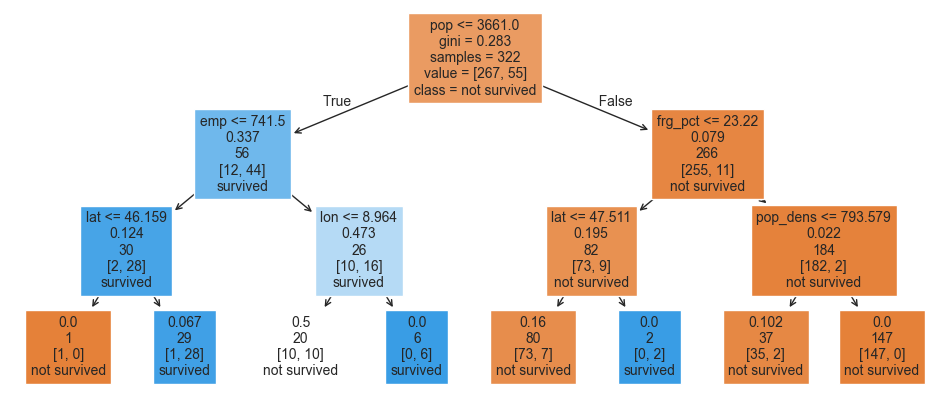

In [32]:
# For the meaning of numbers in boxes see root node
fig = plt.figure(figsize=(12,5))
tree_plot = tree.plot_tree(clf,
                   feature_names=list(X_train.columns),
                   class_names=['not survived', 'survived'],
                   filled=True,
                   fontsize=10,
                   label='root')

## Random Forest Classifier
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [33]:
# Create train and test samples
X2_train, X2_test, y2_train, y2_test = train_test_split(df_sub[['lat',
                                                                         'lon',
                                                                         'pop',
                                                                         'pop_dens',
                                                                         'frg_pct',
                                                                         'emp']],
                                                        df_sub['brand'],
                                                        test_size=0.20,
                                                        random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
            lat       lon     pop     pop_dens    frg_pct       emp
2744  46.477959  8.800118    2889    21.787330  20.318449    1132.0
1783  47.346669  7.909449   18399  1601.305483  29.278765   22016.0
12    47.375255  8.536107  420217  4778.994655  32.458468  491193.0
65    47.403796  8.573042  420217  4778.994655  32.458468  491193.0
920   47.373810  8.641065    8689  1361.912226  24.214524    2946.0 

y2_train:
2744    Migros
1783    Migros
12      Migros
65      Migros
920     Migros
Name: brand, dtype: object


### Fit the Random Forest Classifier

In [34]:
# Initialize the random forest classifier
rfc = RandomForestClassifier(random_state=20, max_depth=10)

# Train the random forest classifier
rfc = rfc.fit(X2_train, y2_train)

# Predict the target variable
y_pred_rf = rfc.predict(X2_test)

print('Predicted target variable (brand)')
y_pred_rf

Predicted target variable (brand)


array(['Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Volg', 'Migros', 'Migros',
       'Volg', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Volg',
       'Migros', 'Migros', 'Migros', 'Volg', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Volg', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Volg', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Volg', 'Migros',
       'Migros', 'Migros', 'Migros', 'Volg', 'Migros', 'Migros', 'Migros',
       'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Migros', 'Volg'],
      dtype=object)

### Show confusion matrix and classification report

In [35]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y2_test, y_pred_rf), '\n')

# Classification report
print('Classification report')
print(classification_report(y2_test, y_pred_rf))

Confusion matrix
[[65  3]
 [ 7  6]] 

Classification report
              precision    recall  f1-score   support

      Migros       0.90      0.96      0.93        68
        Volg       0.67      0.46      0.55        13

    accuracy                           0.88        81
   macro avg       0.78      0.71      0.74        81
weighted avg       0.86      0.88      0.87        81



### Show feature importance

Index(['pop', 'emp', 'pop_dens', 'frg_pct', 'lat', 'lon'], dtype='object')
[0.35636663 0.20295084 0.15575958 0.12214365 0.0860743  0.07670501]


<Axes: ylabel='features'>

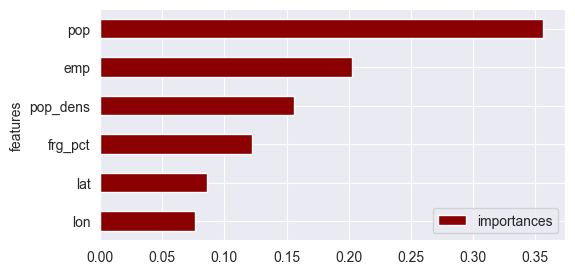

In [36]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = rfc.feature_importances_
std = np.std([tree.feature_importances_ for tree in rfc.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh',
           y='importances',
           x='features',
           color='darkred',
           figsize=(6,3))

### ROC curve and AUC

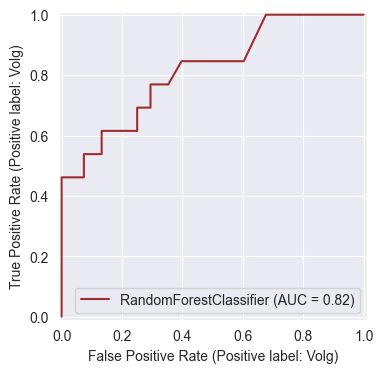

In [37]:
# Plot ROC curve and calculate AUC
plt.figure(figsize=(6,4))
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(rfc,
                                          X2_test,
                                          y2_test,
                                          ax=ax,
                                          alpha=0.8,
                                          c="darkred")
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [38]:
### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
NT
Windows | 11
Datetime: 2025-12-02 09:47:02
Python Version: 3.13.7
-----------------------------------
